# Notebook 05: Platform Dominance Over Time

## Objective

This notebook examines how video game platform dominance changed over time.

Platform performance will be evaluated using annual global sales and yearly market share rather than total lifetime sales alone. This makes it possible to compare platforms within the same year and identify when different platforms became dominant.

The analysis will also examine each platform's active sales period, peak sales year, and strongest period of market performance.

The broader implications, limitations, and connections to the other research questions will be discussed in the final project report.

## Research Question

**How has platform dominance changed over time, and which platforms led the market during different periods?**

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid")

In [3]:
data_path = Path("../../data/processed/video_game_sales_cleaned.csv")

df = pd.read_csv(data_path)

df.head()

,name,platform,year,genre,publisher,na_sales,eu_sales,jp_sales,other_sales,global_sales,regional_sales_total,decade,sales_tier,is_high_seller,na_sales_share,eu_sales_share,jp_sales_share,other_sales_share,dominant_region
0,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,82.74,2000s,blockbuster,1,0.50,0.35,0.05,0.10,North America
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,40.24,1980s,blockbuster,1,0.72,0.09,0.17,0.02,North America
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,35.83,2000s,blockbuster,1,0.44,0.36,0.11,0.09,North America
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,33.00,2000s,blockbuster,1,0.48,0.33,0.10,0.09,North America
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,31.38,1990s,blockbuster,1,0.36,0.28,0.33,0.03,North America


In [4]:
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (16287, 19)


,name,platform,year,genre,publisher,na_sales,eu_sales,jp_sales,other_sales,global_sales,regional_sales_total,decade,sales_tier,is_high_seller,na_sales_share,eu_sales_share,jp_sales_share,other_sales_share,dominant_region
0,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,82.74,2000s,blockbuster,1,0.50,0.35,0.05,0.10,North America
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,40.24,1980s,blockbuster,1,0.72,0.09,0.17,0.02,North America
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,35.83,2000s,blockbuster,1,0.44,0.36,0.11,0.09,North America
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,33.00,2000s,blockbuster,1,0.48,0.33,0.10,0.09,North America
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,31.38,1990s,blockbuster,1,0.36,0.28,0.33,0.03,North America


In [5]:
required_columns = {
    "platform",
    "year",
    "global_sales"
}

missing_columns = required_columns.difference(df.columns)

if missing_columns:
    raise ValueError(
        f"The dataset is missing required columns: {sorted(missing_columns)}"
    )

df[["platform", "year", "global_sales"]].info()

<class 'pandas.DataFrame'>
RangeIndex: 16287 entries, 0 to 16286
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   platform      16287 non-null  str    
 1   year          16287 non-null  int64  
 2   global_sales  16287 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 381.9 KB


In [6]:
platform_year_sales = (
    df.groupby(["year", "platform"], as_index=False)
      .agg(
          global_sales=("global_sales", "sum"),
          game_count=("name", "count")
      )
)

platform_year_sales.head()

,year,platform,global_sales,game_count
0,1980,2600,11.38,9
1,1981,2600,35.77,46
2,1982,2600,28.86,36
3,1983,2600,5.83,11
4,1983,NES,10.96,6


In [7]:
yearly_market_sales = (
    platform_year_sales.groupby("year", as_index=False)
                       .agg(
                           yearly_global_sales=("global_sales", "sum"),
                           yearly_game_count=("game_count", "sum")
                       )
)

yearly_market_sales.head()

,year,yearly_global_sales,yearly_game_count
0,1980,11.38,9
1,1981,35.77,46
2,1982,28.86,36
3,1983,16.79,17
4,1984,50.36,14


In [8]:
platform_market_share = platform_year_sales.merge(
    yearly_market_sales,
    on="year",
    how="left"
)

platform_market_share["market_share"] = (
    platform_market_share["global_sales"]
    / platform_market_share["yearly_global_sales"]
)

platform_market_share["market_share_pct"] = (
    platform_market_share["market_share"] * 100
)

platform_market_share.head()

,year,platform,global_sales,game_count,yearly_global_sales,yearly_game_count,market_share,market_share_pct
0,1980,2600,11.38,9,11.38,9,1.00,100.00
1,1981,2600,35.77,46,35.77,46,1.00,100.00
2,1982,2600,28.86,36,28.86,36,1.00,100.00
3,1983,2600,5.83,11,16.79,17,0.35,34.72
4,1983,NES,10.96,6,16.79,17,0.65,65.28


In [9]:
yearly_platform_leaders = (
    platform_market_share.loc[
        platform_market_share.groupby("year")["market_share"].idxmax()
    ]
    .sort_values("year")
    .reset_index(drop=True)
)

yearly_platform_leaders = yearly_platform_leaders[
    [
        "year",
        "platform",
        "global_sales",
        "yearly_global_sales",
        "market_share_pct",
        "game_count"
    ]
]

yearly_platform_leaders.head()

,year,platform,global_sales,yearly_global_sales,market_share_pct,game_count
0,1980,2600,11.38,11.38,100.00,9
1,1981,2600,35.77,35.77,100.00,46
2,1982,2600,28.86,28.86,100.00,36
3,1983,NES,10.96,16.79,65.28,6
4,1984,NES,50.09,50.36,99.46,13


In [10]:
platform_lifecycle = (
    platform_year_sales.groupby("platform", as_index=False)
                       .agg(
                           first_year=("year", "min"),
                           last_year=("year", "max"),
                           active_years=("year", "nunique"),
                           lifetime_global_sales=("global_sales", "sum"),
                           average_annual_sales=("global_sales", "mean"),
                           peak_annual_sales=("global_sales", "max")
                       )
)

platform_lifecycle["sales_period"] = (
    platform_lifecycle["last_year"]
    - platform_lifecycle["first_year"]
    + 1
)

platform_lifecycle = platform_lifecycle.sort_values(
    "lifetime_global_sales",
    ascending=False
).reset_index(drop=True)

platform_lifecycle.head(10)

,platform,first_year,last_year,active_years,lifetime_global_sales,average_annual_sales,peak_annual_sales,sales_period
0,PS2,2000,2011,12,"1,233.46",102.79,211.78,12
1,X360,2005,2016,12,969.60,80.80,171.05,12
2,PS3,2006,2016,11,949.35,86.30,159.37,11
3,Wii,2006,2015,10,909.81,90.98,210.44,10
4,DS,1985,2014,12,818.62,68.22,149.36,30
5,PS,1994,2003,10,727.39,72.74,169.58,10
6,GBA,2000,2007,8,305.62,38.20,74.38,8
7,PSP,2004,2015,12,291.71,24.31,55.85,12
8,PS4,2013,2016,4,278.07,69.52,115.30,4
9,PC,1985,2016,26,254.70,9.80,35.06,32


In [11]:
platform_peak_years = (
    platform_year_sales.loc[
        platform_year_sales.groupby("platform")["global_sales"].idxmax()
    ]
    .rename(
        columns={
            "year": "peak_year",
            "global_sales": "peak_year_sales",
            "game_count": "peak_year_game_count"
        }
    )
    .reset_index(drop=True)
)

platform_peak_years.head()

,peak_year,platform,peak_year_sales,peak_year_game_count
0,1981,2600,35.77,46
1,1995,3DO,0.08,2
2,2011,3DS,62.53,116
3,2000,DC,5.99,20
4,2007,DS,149.36,377


In [12]:
platform_summary = platform_lifecycle.merge(
    platform_peak_years,
    on="platform",
    how="left"
)

platform_summary = platform_summary[
    [
        "platform",
        "first_year",
        "last_year",
        "active_years",
        "sales_period",
        "lifetime_global_sales",
        "average_annual_sales",
        "peak_year",
        "peak_year_sales",
        "peak_year_game_count"
    ]
]

platform_summary.head(10)

,platform,first_year,last_year,active_years,sales_period,lifetime_global_sales,average_annual_sales,peak_year,peak_year_sales,peak_year_game_count
0,PS2,2000,2011,12,12,"1,233.46",102.79,2004,211.78,259
1,X360,2005,2016,12,12,969.60,80.80,2010,171.05,182
2,PS3,2006,2016,11,11,949.35,86.30,2011,159.37,216
3,Wii,2006,2015,10,10,909.81,90.98,2009,210.44,325
4,DS,1985,2014,12,30,818.62,68.22,2007,149.36,377
5,PS,1994,2003,10,10,727.39,72.74,1998,169.58,248
6,GBA,2000,2007,8,8,305.62,38.20,2002,74.38,198
7,PSP,2004,2015,12,12,291.71,24.31,2006,55.85,190
8,PS4,2013,2016,4,4,278.07,69.52,2015,115.30,137
9,PC,1985,2016,26,32,254.70,9.80,2011,35.06,137


In [13]:
platform_summary = platform_lifecycle.merge(
    platform_peak_years,
    on="platform",
    how="left"
)

platform_summary = platform_summary[
    [
        "platform",
        "first_year",
        "last_year",
        "active_years",
        "sales_period",
        "lifetime_global_sales",
        "average_annual_sales",
        "peak_year",
        "peak_year_sales",
        "peak_year_game_count"
    ]
]

platform_summary.head(10)

,platform,first_year,last_year,active_years,sales_period,lifetime_global_sales,average_annual_sales,peak_year,peak_year_sales,peak_year_game_count
0,PS2,2000,2011,12,12,"1,233.46",102.79,2004,211.78,259
1,X360,2005,2016,12,12,969.60,80.80,2010,171.05,182
2,PS3,2006,2016,11,11,949.35,86.30,2011,159.37,216
3,Wii,2006,2015,10,10,909.81,90.98,2009,210.44,325
4,DS,1985,2014,12,30,818.62,68.22,2007,149.36,377
5,PS,1994,2003,10,10,727.39,72.74,1998,169.58,248
6,GBA,2000,2007,8,8,305.62,38.20,2002,74.38,198
7,PSP,2004,2015,12,12,291.71,24.31,2006,55.85,190
8,PS4,2013,2016,4,4,278.07,69.52,2015,115.30,137
9,PC,1985,2016,26,32,254.70,9.80,2011,35.06,137


In [14]:
market_share_check = (
    platform_market_share.groupby("year", as_index=False)
                         .agg(total_market_share=("market_share_pct", "sum"))
)

market_share_check.head()

,year,total_market_share
0,1980,100.00
1,1981,100.00
2,1982,100.00
3,1983,100.00
4,1984,100.00


### Lifetime Platform Sales

The first comparison examines total global sales accumulated by each platform across all available years.

Lifetime sales provide an overview of overall commercial performance, but they do not account for differences in platform lifespan or changes in annual market leadership.

In [15]:
top_platforms_lifetime = (
    platform_summary.nlargest(10, "lifetime_global_sales")
                    .reset_index(drop=True)
                    .copy()
)

top_platforms_lifetime[
    [
        "platform",
        "first_year",
        "last_year",
        "active_years",
        "lifetime_global_sales",
        "peak_year",
        "peak_year_sales"
    ]
]

lifetime_sales_table = (
    top_platforms_lifetime[
        [
            "platform",
            "first_year",
            "last_year",
            "active_years",
            "lifetime_global_sales",
            "peak_year",
            "peak_year_sales"
        ]
    ]
    .rename(
        columns={
            "platform": "Platform",
            "first_year": "First Year",
            "last_year": "Last Year",
            "active_years": "Active Years",
            "lifetime_global_sales": "Lifetime Global Sales",
            "peak_year": "Peak Year",
            "peak_year_sales": "Peak-Year Sales"
        }
    )
)

lifetime_sales_table

,Platform,First Year,Last Year,Active Years,Lifetime Global Sales,Peak Year,Peak-Year Sales
0,PS2,2000,2011,12,"1,233.46",2004,211.78
1,X360,2005,2016,12,969.60,2010,171.05
2,PS3,2006,2016,11,949.35,2011,159.37
3,Wii,2006,2015,10,909.81,2009,210.44
4,DS,1985,2014,12,818.62,2007,149.36
5,PS,1994,2003,10,727.39,1998,169.58
6,GBA,2000,2007,8,305.62,2002,74.38
7,PSP,2004,2015,12,291.71,2006,55.85
8,PS4,2013,2016,4,278.07,2015,115.30
9,PC,1985,2016,26,254.70,2011,35.06


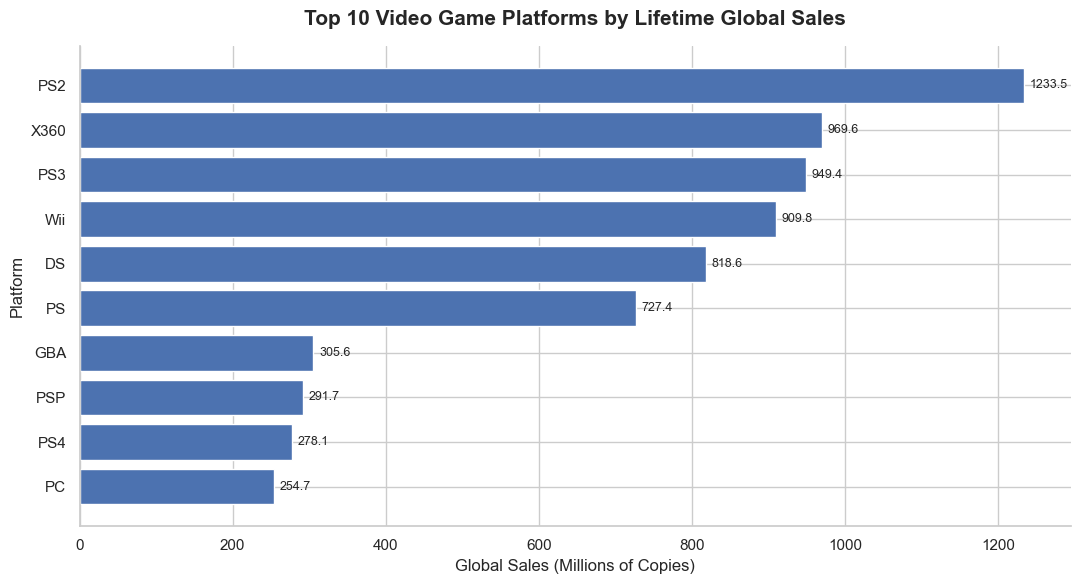

In [17]:
fig, ax = plt.subplots(figsize=(11, 6))

plot_data = top_platforms_lifetime.sort_values(
    "lifetime_global_sales",
    ascending=True
)

bars = ax.barh(
    plot_data["platform"],
    plot_data["lifetime_global_sales"]
)

ax.bar_label(
    bars,
    fmt="%.1f",
    padding=4,
    fontsize=9
)

ax.set_title(
    "Top 10 Video Game Platforms by Lifetime Global Sales",
    fontsize=15,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Global Sales (Millions of Copies)")
ax.set_ylabel("Platform")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Platform Sales Relative to Active Lifespan

Lifetime sales can favour platforms with longer sales periods. Average annual sales are therefore examined as an additional measure of platform performance.

In [19]:
platform_annual_performance = (
    platform_summary[
        [
            "platform",
            "active_years",
            "lifetime_global_sales",
            "average_annual_sales",
            "peak_year",
            "peak_year_sales"
        ]
    ]
    .sort_values("average_annual_sales", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

platform_annual_performance

,platform,active_years,lifetime_global_sales,average_annual_sales,peak_year,peak_year_sales
0,PS2,12,"1,233.46",102.79,2004,211.78
1,Wii,10,909.81,90.98,2009,210.44
2,PS3,11,949.35,86.30,2011,159.37
3,X360,12,969.60,80.80,2010,171.05
4,PS,10,727.39,72.74,1998,169.58
5,PS4,4,278.07,69.52,2015,115.30
6,DS,12,818.62,68.22,2007,149.36
7,3DS,6,246.27,41.05,2011,62.53
8,GBA,8,305.62,38.20,2002,74.38
9,XOne,4,141.06,35.27,2015,57.66


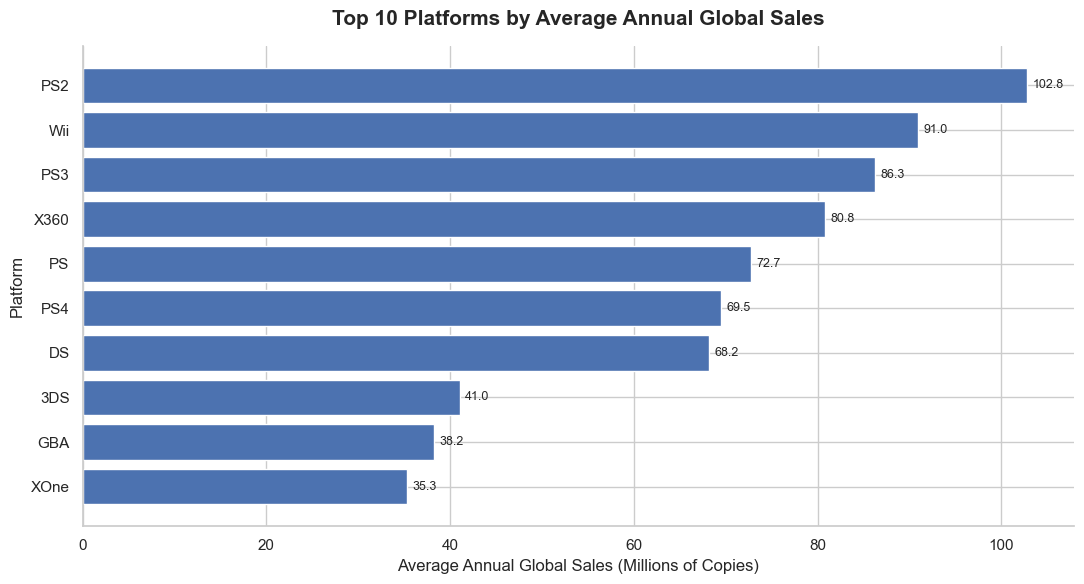

In [20]:
fig, ax = plt.subplots(figsize=(11, 6))

plot_data = platform_annual_performance.sort_values(
    "average_annual_sales",
    ascending=True
)

bars = ax.barh(
    plot_data["platform"],
    plot_data["average_annual_sales"]
)

ax.bar_label(
    bars,
    fmt="%.1f",
    padding=4,
    fontsize=9
)

ax.set_title(
    "Top 10 Platforms by Average Annual Global Sales",
    fontsize=15,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Average Annual Global Sales (Millions of Copies)")
ax.set_ylabel("Platform")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Annual Platform Leaders

Lifetime sales do not show when a platform controlled the market. To examine changes in dominance, the platform with the highest global sales is identified separately for each year.

Yearly market share is calculated as a platform's annual global sales divided by the total global sales of all platforms in the same year.

In [21]:
yearly_leaders_table = (
    yearly_platform_leaders[
        [
            "year",
            "platform",
            "global_sales",
            "yearly_global_sales",
            "market_share_pct",
            "game_count"
        ]
    ]
    .rename(
        columns={
            "year": "Year",
            "platform": "Leading Platform",
            "global_sales": "Platform Sales",
            "yearly_global_sales": "Total Market Sales",
            "market_share_pct": "Market Share (%)",
            "game_count": "Games Released"
        }
    )
)

yearly_leaders_table

,Year,Leading Platform,Platform Sales,Total Market Sales,Market Share (%),Games Released
0,1980,2600,11.38,11.38,100.00,9
1,1981,2600,35.77,35.77,100.00,46
2,1982,2600,28.86,28.86,100.00,36
3,1983,NES,10.96,16.79,65.28,6
4,1984,NES,50.09,50.36,99.46,13
5,1985,NES,53.44,53.94,99.07,11
6,1986,NES,36.41,37.07,98.22,19
7,1987,NES,19.76,21.74,90.89,10
8,1988,NES,45.01,47.22,95.32,11
9,1989,GB,64.98,73.45,88.47,10


In [22]:
platform_leadership_counts = (
    yearly_platform_leaders.groupby("platform", as_index=False)
                           .agg(
                               years_as_leader=("year", "count"),
                               first_leading_year=("year", "min"),
                               last_leading_year=("year", "max"),
                               average_leader_share=(
                                   "market_share_pct",
                                   "mean"
                               )
                           )
                           .sort_values(
                               ["years_as_leader", "average_leader_share"],
                               ascending=[False, False]
                           )
                           .reset_index(drop=True)
)

platform_leadership_counts

,platform,years_as_leader,first_leading_year,last_leading_year,average_leader_share
0,NES,6,1983,1988,91.37
1,PS,6,1995,2000,54.57
2,SNES,5,1990,1994,55.58
3,PS2,5,2001,2005,47.97
4,Wii,4,2006,2009,27.27
5,2600,3,1980,1982,100.00
6,PS4,3,2014,2016,42.75
7,PS3,3,2011,2013,30.97
8,GB,1,1989,1989,88.47
9,X360,1,2010,2010,28.49


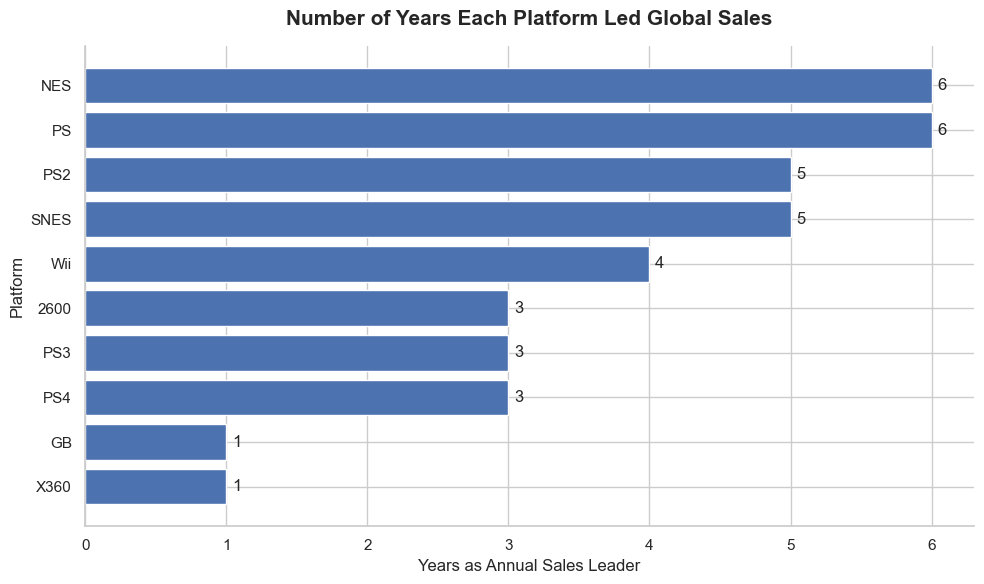

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

plot_data = platform_leadership_counts.sort_values(
    "years_as_leader",
    ascending=True
)

bars = ax.barh(
    plot_data["platform"],
    plot_data["years_as_leader"]
)

ax.bar_label(
    bars,
    fmt="%d",
    padding=4
)

ax.set_title(
    "Number of Years Each Platform Led Global Sales",
    fontsize=15,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Years as Annual Sales Leader")
ax.set_ylabel("Platform")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()